In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
from matplotlib.colors import LinearSegmentedColormap
import os

In [2]:
nt_mapping = {'Gaba-Chol':'Chol',
             'Chol':'Chol',
             'Glut-Chol':'Chol',
             'Glut-Gaba-Dopa':'Dopa',
             'Gaba-Dopa':'Dopa',
             'Dopa-Gaba':'Dopa',
             'Glut-Dopa':'Dopa',
             'Gaba-Dopa-Chol':'Dopa',
             'Dopa':'Dopa',
             'Gly':'Gly',
             'Hist':'Hist',
             'Gaba':'Gaba',
             'Glut':'Glut',
             'Gaba-Glut':'Gaba-Glut',
             'Glut-Gaba':'Gaba-Glut',
             'Gaba-Gly':'Gly',
             'Glut-Gly': 'Gly',
             'Glut-Gaba-Gly':'Gly',
             'Gaba-Hist':'Hist',
             'Hist-Gaba':'Hist',
             'Nora':'Nora',
             'Gaba-Sert':'Sert',
             'Glut-Sert':'Sert',
             'unclear':'Unclear',
             'Sert':'Sert',
             'Glut-Gaba-Sert':'Sert',
             'Glut-Sert-Gly':'Sert',
             'Gaba-Dopa-Sert':'Sert',
             'Glut-Gaba-Hist':'Hist',
             'Glut-Gaba-Sert-Hist':'Hist'}

In [3]:
NT_df = pd.DataFrame(data = np.zeros((6,len(list(set(nt_mapping.values()))))),columns = list(set(nt_mapping.values())), index = ['mg','mo','cj','ac','xt','dr'])

In [4]:
sam = SAM()
sam.load_data('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad')

In [5]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc',
       'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm',
       'neurotransmitter', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled',
       'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2',
       'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2'],
      dtype='object')

In [6]:
sam.adata[sam.adata.obs['neurotransmitter_v2'] == 'unclear']

View of AnnData object with n_obs × n_vars = 2463 × 27977
    obs: 'n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [7]:
org = 'dr'

In [ ]:
for item in sam.adata.obs['subclass_id_label'].unique():
    NT_name = item.split(' ')[-1]
    if '-' not in NT_name:
        NT_df.loc[org,NT_name] += len(sam.adata[sam.adata.obs['subclass_id_label'] == item])
    elif NT_name == 'Gaba-Glut':
        NT_df.loc[org,NT_name] += len(sam.adata[sam.adata.obs['subclass_id_label'] == item])
    else:
        NT_name = NT_name.split('-')[0]
        NT_df.loc[org,NT_name] += len(sam.adata[sam.adata.obs['subclass_id_label'] == item])

In [8]:
for item in sam.adata.obs['neurotransmitter_v2'].unique():
    if item not in nt_mapping:
        print(item)

In [9]:
for item in sam.adata.obs['neurotransmitter_v2'].unique():
    NT_df.loc[org,nt_mapping[item]] += len(sam.adata[sam.adata.obs['neurotransmitter_v2'] == item])

In [10]:
NT_df = NT_df[['Gaba','Glut','Gaba-Glut','Sert','Dopa','Gly','Hist','Nora','Chol']]

In [11]:
NT_df_gg = NT_df[['Gaba-Glut','Sert','Dopa','Gly','Hist','Nora','Chol']]

In [12]:
NT_df_gg = NT_df_gg.div(NT_df_gg.sum(axis=1), axis=0)

In [13]:
NT_df = NT_df.div(NT_df.sum(axis=1), axis=0)

In [14]:
NT_df = NT_df.loc[['mo','cj','ac','xt','dr'],:]

In [15]:
NT_df = NT_df.rename({'mo':'prairie vole','cj':'japanese quail','ac':'green anole','xt':'clawed frog','dr':'zebrafish'},axis=0)

In [18]:
NT_df

,Gaba,Glut,Gaba-Glut,Sert,Dopa,Gly,Hist,Nora,Chol
prairie vole,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
japanese quail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
green anole,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clawed frog,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zebrafish,0.301617,0.459921,0.142905,0.093999,0.0,0.0,0.000726,0.0,0.000832


In [20]:
NT_df_gg = NT_df_gg.rename({'mg':'mouse','mo':'prairie vole','cj':'japanese quail','ac':'green anole','xt':'clawed frog','dr':'zebrafish'},axis=0)

In [21]:
NT_df_gg_v2 = NT_df_gg[['Gaba-Glut','Sert','Dopa','Gly','Hist','Nora','Chol']]

In [22]:
color = ['red','blue','black','black','black','black','black','black','black','black']
color_gg = ['#0a9864','#503090','#f9ed4e','#801c59','#f37527','black','#85c77e']

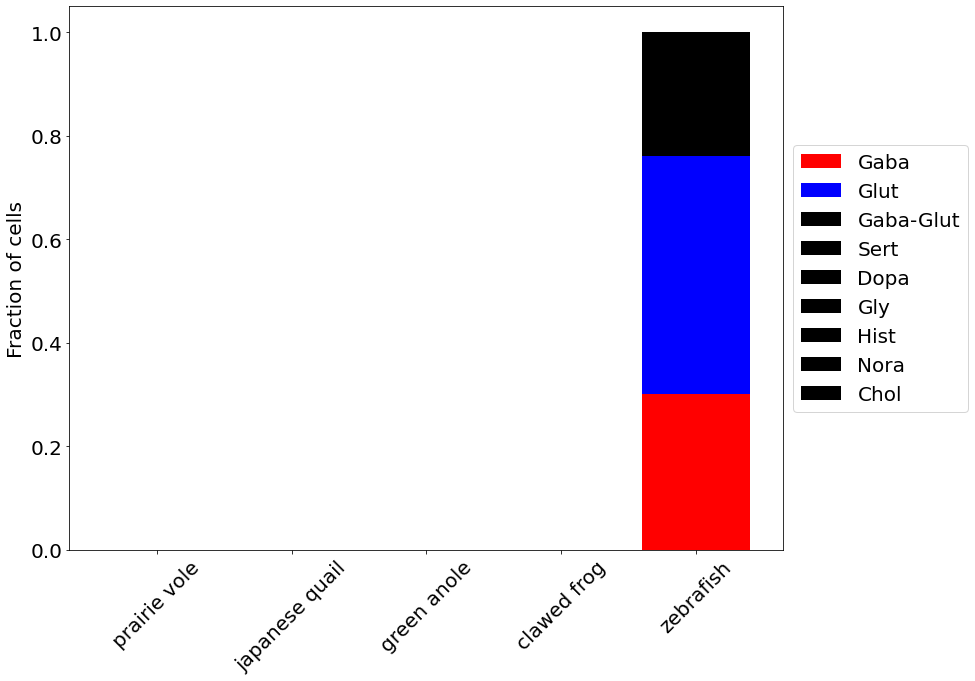

In [33]:
plt.rcParams.update({'font.size': 20}) 
ax = NT_df.plot.bar(stacked=True, figsize = (16,10), width = .8, color = color)
# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Fraction of cells')
plt.xticks(rotation=45) 
plt.savefig('Figures/Figures_07032026/NT_stacked_bar_07012026.pdf')
plt.show()

In [40]:
NT_df

,Gaba,Glut,Gaba-Glut,Sert,Dopa,Gly,Hist,Nora,Chol,Unclear
mg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mo,0.460145,0.508404,0.004935,0.000000,0.012440,0.000000,0.008992,0.0,0.004557,0.000527
cj,0.547268,0.424090,0.000000,0.002511,0.011120,0.000000,0.005058,0.0,0.002672,0.007282
ac,0.478708,0.449587,0.000000,0.004607,0.003290,0.052154,0.002907,0.0,0.005566,0.003181
xt,0.383552,0.437065,0.023658,0.002996,0.017718,0.077581,0.006350,0.0,0.002407,0.048674
dr,0.362724,0.430334,0.119980,0.067537,0.007700,0.000000,0.000700,0.0,0.000802,0.010223


In [106]:
plt.rcParams.update(plt.rcParamsDefault)

In [37]:
pd.read_csv('NT/MO.nt.type.csv', index_col = 'subclass').loc['092 TMv-PMv Tbx3 Hist-Gaba',:]

Unnamed: 0            17
Glut                   0
Gaba                   1
Dopa                   0
Chol                   0
Sert                   0
Nora                   0
Gly                    0
Hist                   0
Neurotransmitter    Gaba
Name: 092 TMv-PMv Tbx3 Hist-Gaba, dtype: object